# Task 8 — Normalization and Standardization

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler


Before scaling:
         age    income  loan_amount  credit_score  employment_years
count  270.0     270.0        270.0         270.0             270.0
mean    38.7   61388.3      33263.6         580.8               9.4
std     10.1   58847.4      32677.5         132.1               5.6
min     22.0   20384.0       5009.0           5.0               0.0
25%     29.0   40152.2      17204.0         472.5               4.0
50%     40.0   56301.5      31199.0         594.5              10.0
75%     47.0   77769.0      46165.0         680.5              14.0
max     54.0  950000.0     500000.0         799.0              19.0


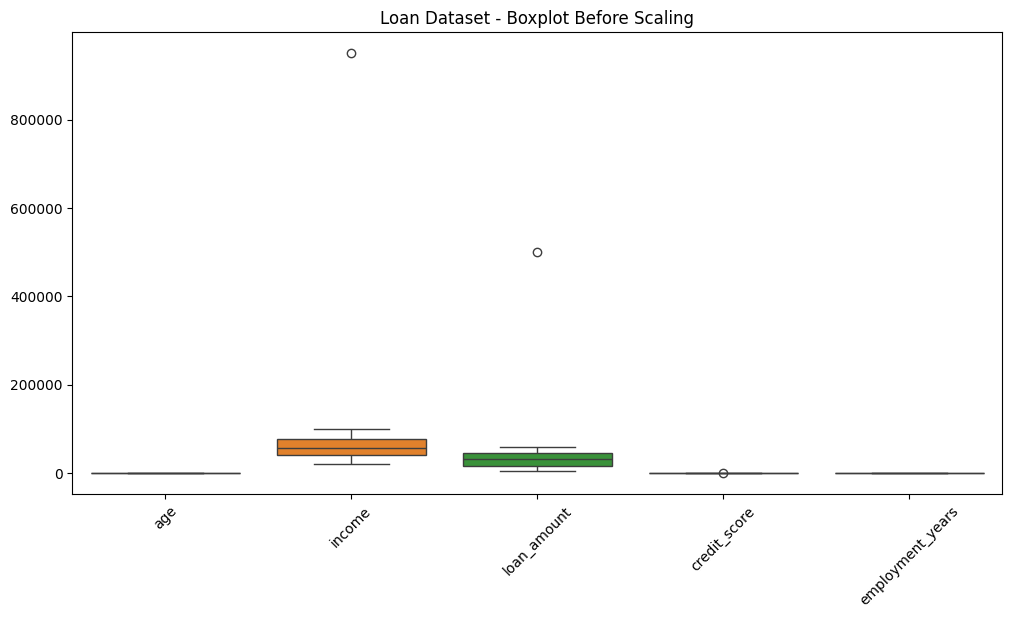

In [9]:

df = pd.read_csv("../data/loan_data.csv")
df.dropna(inplace=True)
df = df.drop_duplicates().reset_index(drop=True)

cols = ['age', 'income', 'loan_amount', 'credit_score', 'employment_years']
print("Before scaling:")
print(df[cols].describe().round(1))


plt.figure(figsize=(12,6))

sns.boxplot(data=df[cols])

plt.title("Loan Dataset - Boxplot Before Scaling")
plt.xticks(rotation=45)

plt.show()

### Min-Max Normalization
Scales values to range [0, 1]. Formula: `(x - min) / (max - min)`

Use when: you need values between 0 and 1. Sensitive to outliers.

After Min-Max Normalization:
           age   income  loan_amount  credit_score  employment_years
count  270.000  270.000      270.000       270.000           270.000
mean     0.522    0.044        0.057         0.725             0.497
std      0.317    0.063        0.066         0.166             0.296
min      0.000    0.000        0.000         0.000             0.000
25%      0.219    0.021        0.025         0.589             0.211
50%      0.562    0.039        0.053         0.742             0.526
75%      0.781    0.062        0.083         0.851             0.737
max      1.000    1.000        1.000         1.000             1.000


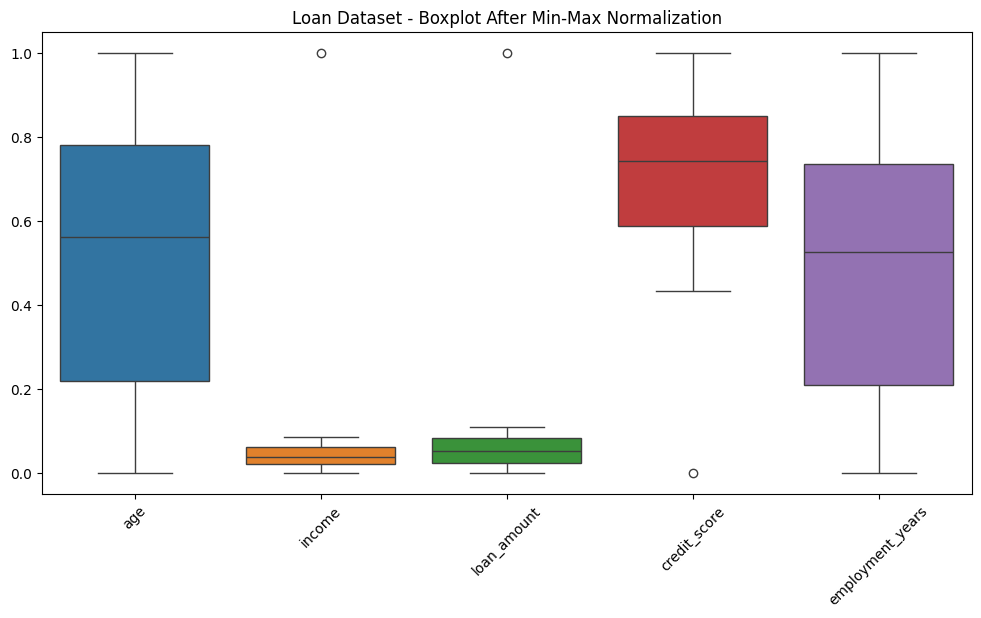

In [10]:
mm = MinMaxScaler()
df_normalized = df.copy()
df_normalized[cols] = mm.fit_transform(df[cols])

print("After Min-Max Normalization:")
print(df_normalized[cols].describe().round(3))

plt.figure(figsize=(12,6))
sns.boxplot(data=df_normalized[cols])
plt.title("Loan Dataset - Boxplot After Min-Max Normalization")
plt.xticks(rotation=45)
plt.show()

### Standardization (Z-score)
Transforms to mean=0 and std=1. Formula: `(x - mean) / std`

Use when: algorithm assumes Gaussian distribution (Logistic Regression, SVM, Neural Networks).

After Standardization:
           age   income  loan_amount  credit_score  employment_years
count  270.000  270.000      270.000       270.000           270.000
mean    -0.000   -0.000        0.000        -0.000            -0.000
std      1.002    1.002        1.002         1.002             1.002
min     -1.649   -0.698       -0.866        -4.367            -1.681
25%     -0.958   -0.362       -0.492        -0.821            -0.969
50%      0.129   -0.087       -0.063         0.104             0.099
75%      0.820    0.279        0.396         0.756             0.811
max      1.511   15.128       14.310         1.655             1.701


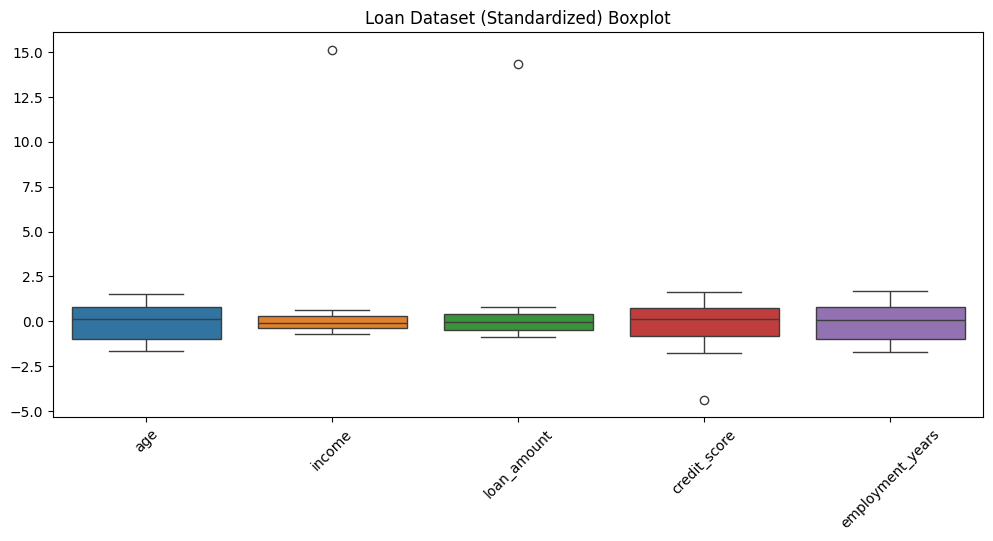

In [11]:
ss = StandardScaler()
df_standardized = df.copy()
df_standardized[cols] = ss.fit_transform(df[cols])

print("After Standardization:")
print(df_standardized[cols].describe().round(3))

plt.figure(figsize=(12,5))
sns.boxplot(data=df_standardized[cols])
plt.title("Loan Dataset (Standardized) Boxplot")
plt.xticks(rotation=45)
plt.show()